# Demo 2 — Seleksi Fitur pada Data Teks

## Tujuan
Mahasiswa memahami:
* teks tidak bisa langsung digunakan model,
* teks harus direpresentasikan menjadi fitur numerik,
* kata tertentu lebih informatif dibanding kata lain.

## Tahap 1 — Tampilkan Teks Asli
Kita menggunakan dataset dummy review produk/restoran.

In [1]:
import pandas as pd

data = {
    'review': [
        'makanan di sini sangat enak dan pelayanannya bagus',
        'tempatnya kotor dan pelayannya lambat',
        'rasa makanannya biasa saja tapi harganya mahal',
        'saya sangat suka menu barunya, sungguh lezat',
        'pelayanan sangat buruk, saya tidak akan kembali',
        'suasananya nyaman dan makanannya lumayan',
        'restoran terburuk yang pernah saya kunjungi, menjijikkan',
        'enak sekali! pasti akan datang lagi bersama keluarga',
        'harganya tidak sebanding dengan rasa makanannya',
        'pelayanan luar biasa cepat dan ramah'
    ],
    'sentiment': [1, 0, 0, 1, 0, 1, 0, 1, 0, 1]  # 1: Positif, 0: Negatif
}

df = pd.DataFrame(data)
df.head(10)

,review,sentiment
0,makanan di sini sangat enak dan pelayanannya b...,1
1,tempatnya kotor dan pelayannya lambat,0
2,rasa makanannya biasa saja tapi harganya mahal,0
3,"saya sangat suka menu barunya, sungguh lezat",1
4,"pelayanan sangat buruk, saya tidak akan kembali",0
5,suasananya nyaman dan makanannya lumayan,1
6,"restoran terburuk yang pernah saya kunjungi, m...",0
7,enak sekali! pasti akan datang lagi bersama ke...,1
8,harganya tidak sebanding dengan rasa makanannya,0
9,pelayanan luar biasa cepat dan ramah,1


**Insight:** Dataset berisi 10 review restoran dengan label sentimen (1 = Positif, 0 = Negatif). Setiap review adalah teks dalam bahasa Indonesia yang perlu diproses sebelum dapat digunakan oleh model machine learning.

## Tahap 2 — TF-IDF Vectorization
Model ML tidak memahami kata. Model memahami angka. Mari ubah teks menjadi representasi numerik (TF-IDF matrix).

**Apa itu TF-IDF?**
TF-IDF (Term Frequency-Inverse Document Frequency) adalah teknik untuk mengubah teks menjadi vektor numerik. TF mengukur seberapa sering sebuah kata muncul dalam dokumen, sedangkan IDF mengurangi bobot kata yang terlalu umum di seluruh dokumen. Hasilnya adalah matriks di mana setiap kata menjadi sebuah kolom/fitur.

**Rumus TF-IDF:**

$$TF(t, d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$$

$$IDF(t, D) = \log\left(\frac{|D|}{|\{d \in D : t \in d\}|}\right)$$

$$TF\text{-}IDF(t, d, D) = TF(t, d) \times IDF(t, D)$$

**Penjelasan Rumus:**
- $TF(t, d)$: Term Frequency - frekuensi kata $t$ dalam dokumen $d$
- $f_{t,d}$: jumlah kemunculan kata $t$ dalam dokumen $d$
- $IDF(t, D)$: Inverse Document Frequency - bobot invers dari frekuensi dokumen yang mengandung kata $t$
- $|D|$: total jumlah dokumen dalam korpus
- $|\{d \in D : t \in d\}|$: jumlah dokumen yang mengandung kata $t$
- $TF\text{-}IDF(t, d, D)$: skor akhir TF-IDF untuk kata $t$ dalam dokumen $d$

Kata yang sering muncul dalam satu dokumen tetapi jarang di seluruh dokumen akan memiliki skor TF-IDF tinggi, artinya kata tersebut sangat informatif dan spesifik untuk dokumen tersebut.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df['review'])
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
print(f"Shape matriks TF-IDF: {df_tfidf.shape}")
df_tfidf#.head(3)

Shape matriks TF-IDF: (10, 50)


,akan,bagus,barunya,bersama,biasa,buruk,cepat,dan,datang,dengan,...,sekali,sini,suasananya,suka,sungguh,tapi,tempatnya,terburuk,tidak,yang
0,0.000000,0.385959,0.00000,0.000000,0.000000,0.000000,0.000000,0.255207,0.000000,0.000000,...,0.000000,0.385959,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.313903,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.474727,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.00000,0.000000,0.355407,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.418081,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.40468,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.40468,0.40468,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.370157,0.000000,0.00000,0.000000,0.000000,0.435432,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.370157,0.000000
5,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.331014,0.000000,0.000000,...,0.000000,0.000000,0.500604,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.390639,0.000000,0.390639
7,0.311547,0.000000,0.00000,0.366487,0.000000,0.000000,0.000000,0.000000,0.366487,0.000000,...,0.366487,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.460234,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.391241,0.000000
9,0.000000,0.000000,0.00000,0.000000,0.384718,0.000000,0.452561,0.299247,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


**Insight:** Setiap kata menjadi sebuah kolom/fitur (dimensi). Dari 10 review, kita mendapatkan 50 kata unik sebagai fitur. Ini berarti dimensi data meningkat dari 1 kolom teks menjadi 50 kolom numerik. Tidak semua kata ini sama pentingnya untuk prediksi sentimen.

## Tahap 3 — Seleksi Fitur dengan Chi-Square
Kata mana yang paling informatif untuk menentukan apakah review itu positif atau negatif?

**Apa itu Chi-Square?**
Chi-Square adalah uji statistik yang mengukur hubungan antara dua variabel kategorikal. Dalam konteks seleksi fitur teks, Chi-Square mengukur seberapa kuat hubungan antara keberadaan sebuah kata dengan label sentimen. Semakin tinggi skor Chi-Square, semakin informatif kata tersebut untuk membedakan sentimen.

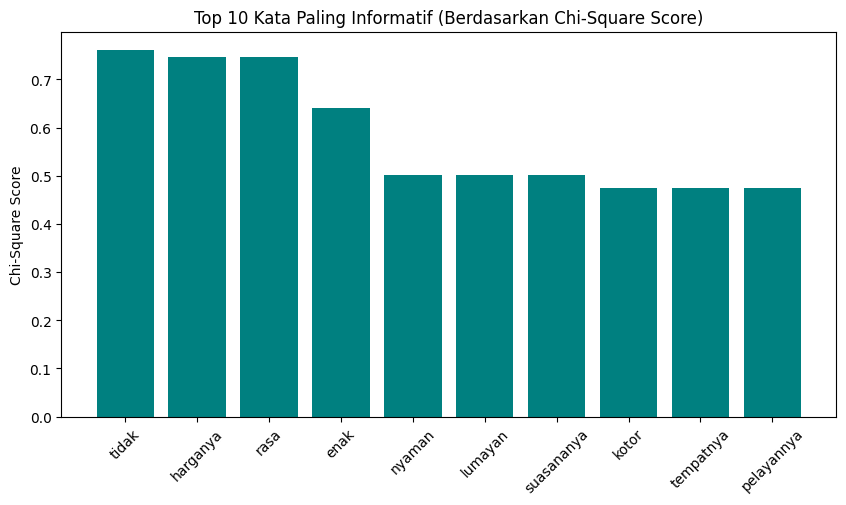

In [3]:
from sklearn.feature_selection import chi2
import matplotlib.pyplot as plt

chi2_scores, p_values = chi2(X_tfidf, df['sentiment'])

# Buat dataframe skor untuk diplot
chi2_df = pd.DataFrame({'kata': feature_names, 'score': chi2_scores}).sort_values('score', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(chi2_df['kata'].head(10), chi2_df['score'].head(10), color='teal')
plt.xticks(rotation=45)
plt.title('Top 10 Kata Paling Informatif (Berdasarkan Chi-Square Score)')
plt.ylabel('Chi-Square Score')
plt.show()

**Insight:** Beberapa kata (seperti 'sangat', 'dan') mungkin sering muncul tapi tidak memberikan informasi kuat terkait sentimen dibanding kata seperti 'enak' atau 'buruk'. Kata-kata dengan skor Chi-Square tinggi lebih informatif untuk membedakan review positif dan negatif.

## Tahap 4 — Visualisasi Kata Penting
Mari buat word cloud agar seleksi kata ini lebih visual dan mudah dipahami.

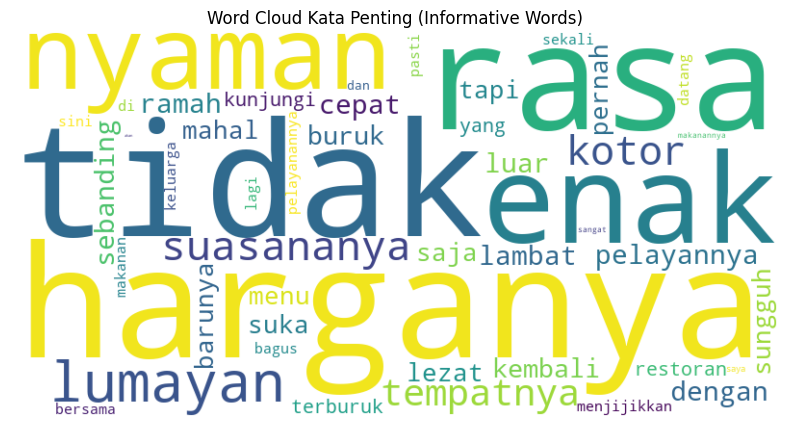

In [4]:
from wordcloud import WordCloud

# Konversi skor chi-square ke dictionary
word_scores = dict(zip(chi2_df['kata'], chi2_df['score']))

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(word_scores)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Kata Penting (Informative Words)')
plt.show()

**Insight:** Word cloud menampilkan kata-kata penting dengan ukuran yang proporsional terhadap skor Chi-Square mereka. Kata yang lebih besar berarti lebih informatif untuk memprediksi sentimen. Ini membantu kita memahami kata-kata mana yang paling membedakan review positif dan negatif.

## Tahap 5 — Insight Penutup
* Tidak semua kata penting.
* Kata umum sering tidak informatif (noise).
* Seleksi fitur membantu model fokus pada kata penting dan mengurangi dimensi/ukuran data.

**Kesimpulan:** Seleksi fitur pada data teks berarti **memilih kata penting**.